# Part 2: CNN using PyTorch with GradCAM

---

1. **Design** a CNN with less than 1 million parameters using PyTorch
2. **Train** the model on CIFAR-10
3. **Visualize** predictions and confusion matrices
4. **Use** GradCAM (provided) for visual explanations
5. **Implement** visualization functions to analyze attention regions at different layers

**Dataset**: CIFAR-10 (60,000 color 32×32 images, 10 classes)

## Part 0: Environment Setup & Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tqdm.auto import tqdm
import time
import cv2

# Set seeds for reproducibility (DO NOT MODIFY)
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Configuration (DO NOT MODIFY)
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

BATCH_SIZE = 128
LEARNING_RATE = 1e-3
NUM_EPOCHS = 15
NUM_CLASSES = 10

## Part 1: Data Loading

In [ ]:
# Data loading (provided)
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

100%|██████████| 170M/170M [00:19<00:00, 8.93MB/s] 


Training samples: 50000
Test samples: 10000
Image shape: torch.Size([3, 32, 32])


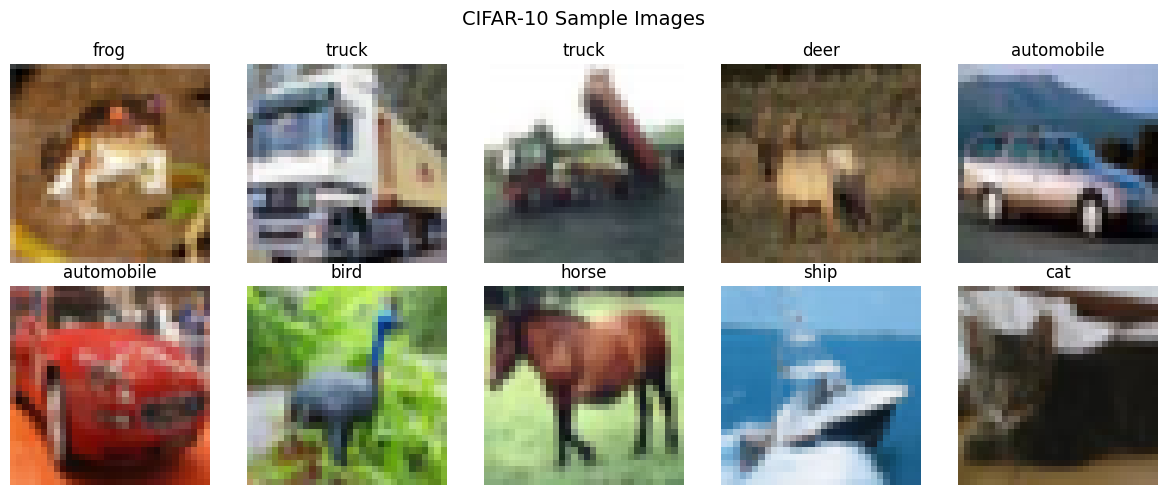

In [ ]:
# Visualize sample images (provided)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

viz_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())

for i, ax in enumerate(axes.flat):
    img, label = viz_dataset[i]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(CLASS_NAMES[label])
    ax.axis('off')
plt.suptitle('CIFAR-10 Sample Images', fontsize=14)
plt.tight_layout()
plt.show()

## Part 2: Efficient CNN Architecture (<1M Parameters)

Design a CNN with **less than 1 million parameters** that achieves good accuracy on CIFAR-10.

In [ ]:
class EfficientCNN(nn.Module):
    """
    An efficient CNN for CIFAR-10 with less than 1M parameters.

    Requirements:
        - Total parameters < 1,000,000
        - Must use convolutional layers
        - Must achieve reasonable accuracy (aim for >80%)
    """

    def __init__(self, num_classes=10):
        super(EfficientCNN, self).__init__()

        # TODO: Design your efficient CNN architecture
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)


    def forward(self, x):
        """
        Forward pass.

        Args:
            x: Input tensor of shape (batch_size, 3, 32, 32)

        Returns:
            Output tensor of shape (batch_size, num_classes)
        """
        # TODO: Implement forward pass
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.dropout(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        x = self.dropout(x)
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool3(x)
        x = self.dropout(x)

        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

In [ ]:
def count_parameters(model):
    """Count total trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Verify architecture
model = EfficientCNN(num_classes=NUM_CLASSES).to(device)
print(model)

# Test forward pass
dummy_input = torch.randn(2, 3, 32, 32).to(device)
dummy_output = model(dummy_input)

# Verify constraints
num_params = count_parameters(model)
print(f"\n✓ Input shape: {dummy_input.shape}")
print(f"✓ Output shape: {dummy_output.shape}")
print(f"\nTotal parameters: {num_params:,}")

if num_params < 1_000_000:
    print("✓ Parameter constraint satisfied (<1M)")
else:
    print(f"✗ Too many parameters! Need to reduce by {num_params - 1_000_000:,}")

EfficientCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_run

## Part 3: Training

Implement the training and evaluation functions.

In [ ]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train for one epoch.

    Args:
        model: The CNN model
        train_loader: DataLoader for training data
        criterion: Loss function
        optimizer: Optimizer
        device: cuda or cpu

    Returns:
        avg_loss: Average loss over all batches
        accuracy: Training accuracy (percentage)
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)

        # TODO: Implement training step
        # 1. Zero gradients
        # 2. Forward pass
        # 3. Compute loss
        # 4. Backward pass
        # 5. Update weights
        # 6. Update running_loss, correct, total
        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()


    return running_loss / len(train_loader), 100. * correct / total


def evaluate(model, test_loader, criterion, device):
    """
    Evaluate on test set.

    Args:
        model: The CNN model
        test_loader: DataLoader for test data
        criterion: Loss function
        device: cuda or cpu

    Returns:
        avg_loss: Average test loss
        accuracy: Test accuracy (percentage)
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Evaluating', leave=False):
            images, labels = images.to(device), labels.to(device)

            # TODO: Implement evaluation step
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(test_loader), 100. * correct / total

In [ ]:
def train_model(model, train_loader, test_loader, num_epochs, learning_rate, device):
    """Full training loop with Adam optimizer."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': []
    }

    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        epoch_time = time.time() - start_time

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}% | "
              f"Time: {epoch_time:.1f}s")

    return history

In [ ]:
# Train the model
print("="*60)
print("Training Efficient CNN")
print("="*60)

model = EfficientCNN(num_classes=NUM_CLASSES).to(device)
history = train_model(
    model, train_loader, test_loader,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE, device=device
)

print(f"\nFinal Test Accuracy: {history['test_acc'][-1]:.2f}%")

Training Efficient CNN


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [1/15] Train Loss: 1.4134, Train Acc: 48.36% | Test Loss: 1.4305, Test Acc: 51.46% | Time: 13.1s


Training:   0%|          | 0/391 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [14/15] Train Loss: 0.5364, Train Acc: 81.43% | Test Loss: 0.5228, Test Acc: 82.38% | Time: 12.6s


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [15/15] Train Loss: 0.5277, Train Acc: 81.78% | Test Loss: 0.5243, Test Acc: 82.23% | Time: 12.7s

Final Test Accuracy: 82.23%


## Part 4: Visualizations 

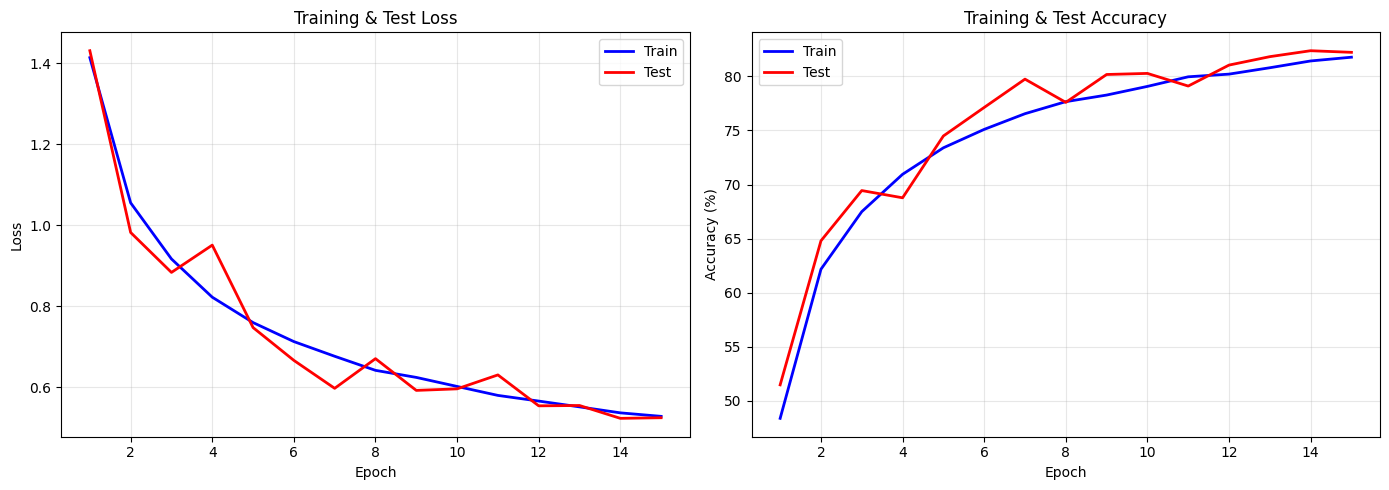

In [ ]:
# Plot training curves (provided)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2)
axes[0].plot(epochs, history['test_loss'], 'r-', label='Test', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Test Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_acc'], 'b-', label='Train', linewidth=2)
axes[1].plot(epochs, history['test_acc'], 'r-', label='Test', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training & Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def get_predictions(model, data_loader, device):
    """Get all predictions and labels from a data loader."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

In [ ]:
def plot_confusion_matrix(model, data_loader, device, class_names, title='Confusion Matrix'):
    """
    Plot confusion matrix for a model.
    """
    # TODO: Implement confusion matrix visualization
    # 1. Get predictions
    # 2. Compute confusion matrix
    # 3. Plot using seaborn heatmap
    predictions, true_labels = get_predictions(model, data_loader, device)

    cm = confusion_matrix(true_labels, predictions)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(title, fontsize=14)
    plt.tight_layout()

<Figure size 1000x800 with 0 Axes>

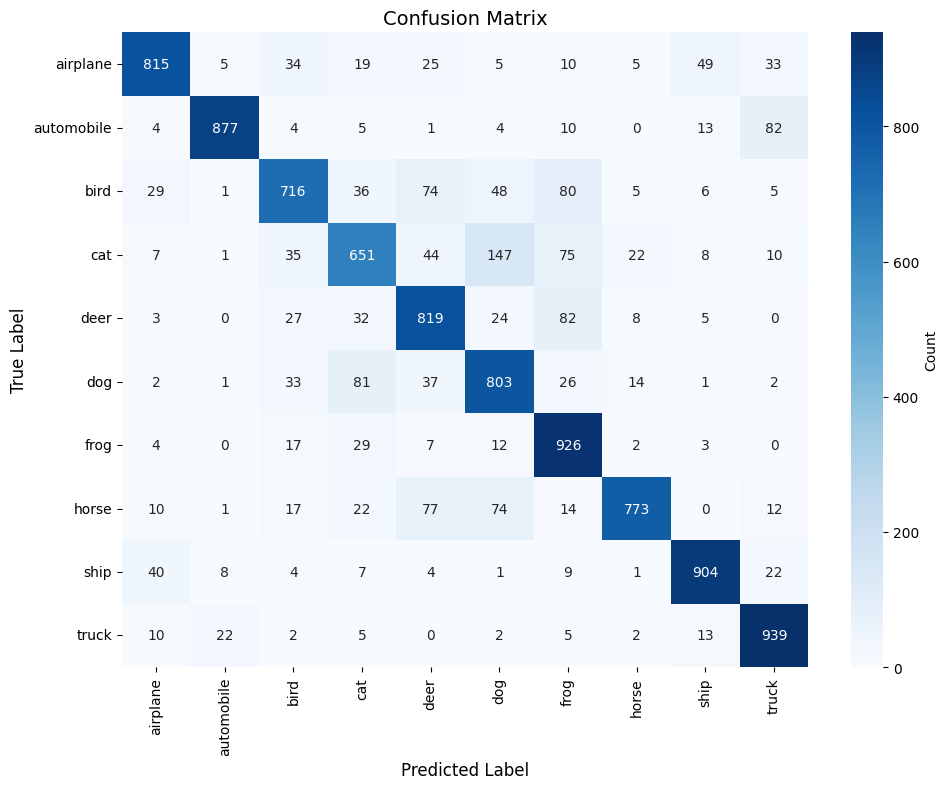

In [ ]:
# Plot confusion matrix
plt.figure(figsize=(10, 8))
plot_confusion_matrix(model, test_loader, device, CLASS_NAMES)
plt.tight_layout()
plt.show()

In [ ]:
def visualize_predictions(model, dataset, device, class_names, num_samples=10):
    """
    Visualize model predictions on sample images.
    """
    # TODO: Implement prediction visualization
    # Show images with true and predicted labels
    # Color correct predictions green, incorrect red
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()

    viz_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transforms.ToTensor())

    for idx, ax in zip(indices, axes):
        image_norm, true_label = dataset[idx]

        image_display, _ = viz_dataset[idx]

        with torch.no_grad():
            image_batch = image_norm.unsqueeze(0).to(device)
            output = model(image_batch)
            _, pred_label = output.max(1)
            pred_label = pred_label.item()

        ax.imshow(image_display.permute(1, 2, 0))
        ax.axis('off')

        color = 'green' if pred_label == true_label else 'red'
        title = f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}"
        ax.set_title(title, color=color, fontsize=10)

    plt.suptitle('Model PredictionGreen=Correct, Red=Incorrect)', fontsize=14)
    plt.tight_layout()
    plt.show()

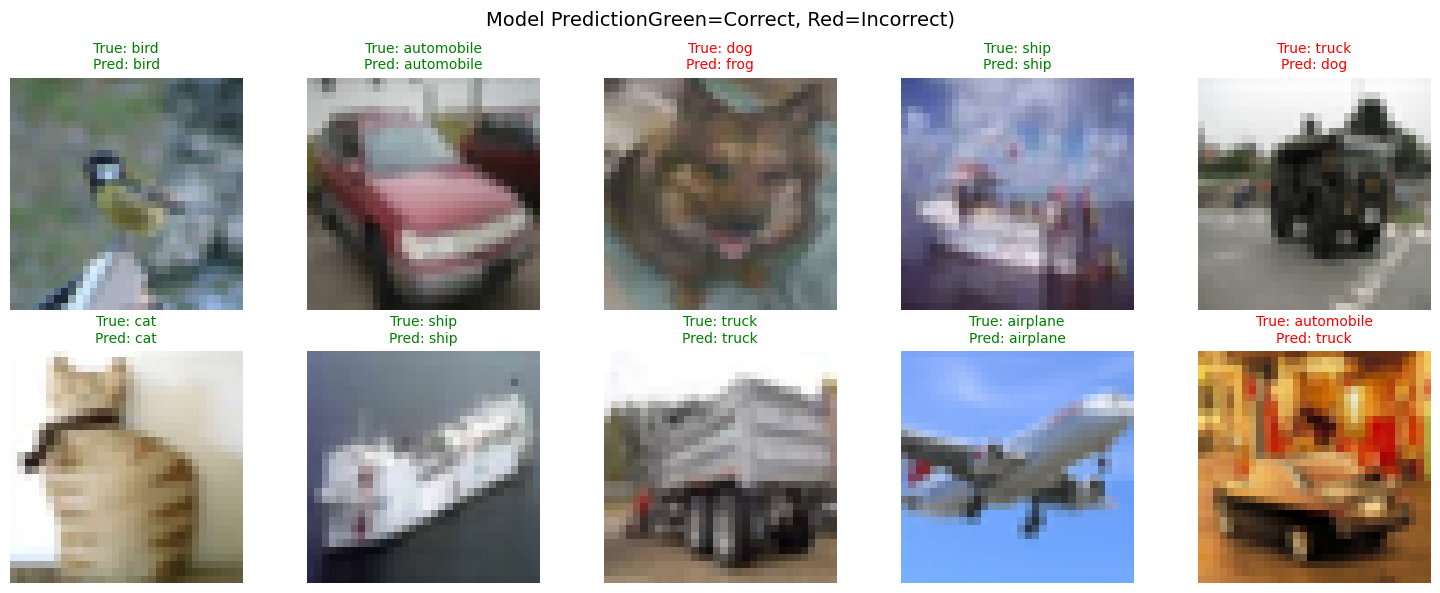

In [ ]:
# Visualize predictions
visualize_predictions(model, test_dataset, device, CLASS_NAMES)

## Part 5: GradCAM Implementation

Implement **Gradient-weighted Class Activation Mapping (GradCAM)** to visualize which regions of an image the CNN focuses on when making predictions.

**GradCAM Algorithm:**
1. Forward pass: Get activations from target layer using a **forward hook**
2. Backward pass: Get gradients flowing into target layer using a **backward hook**
3. Compute importance weights: Global average pool the gradients
4. Compute weighted combination: Sum (weights × activations)
5. Apply ReLU: Keep only positive contributions
6. Upsample to input size

**Key Concepts:**
- Forward hooks capture layer outputs during forward pass
- Backward hooks capture gradients during backward pass
- The heatmap shows which spatial regions contribute most to a class prediction

In [ ]:
class GradCAM:
    """
    GradCAM implementation for CNN visualization (provided).

    Gradient-weighted Class Activation Mapping uses the gradients flowing into
    the final convolutional layer to produce a coarse localization map highlighting
    important regions in the image for prediction.

    Usage:
        gradcam = GradCAM(model, target_layer)
        cam, pred_class = gradcam.generate_cam(input_image)
        gradcam.remove_hooks()  # Clean up after use

    Args:
        model: The trained CNN model
        target_layer: The convolutional layer to compute GradCAM for
    """

    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        # Storage for activations and gradients
        self.activations = None
        self.gradients = None

        # Register hooks
        self.forward_hook = None
        self.backward_hook = None
        self._register_hooks()

    def _register_hooks(self):
        """Register forward and backward hooks on the target layer."""
        def forward_hook_fn(module, input, output):
            self.activations = output.detach()

        def backward_hook_fn(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.forward_hook = self.target_layer.register_forward_hook(forward_hook_fn)
        self.backward_hook = self.target_layer.register_full_backward_hook(backward_hook_fn)

    def remove_hooks(self):
        """Remove registered hooks."""
        if self.forward_hook is not None:
            self.forward_hook.remove()
        if self.backward_hook is not None:
            self.backward_hook.remove()

    def generate_cam(self, input_image, target_class=None):
        """
        Generate GradCAM heatmap for an input image.

        Args:
            input_image: Tensor of shape (1, C, H, W)
            target_class: Class index to compute CAM for (None = predicted class)

        Returns:
            cam: Normalized heatmap of shape (H, W) with values in [0, 1]
            pred_class: Predicted class index
        """
        self.model.eval()
        input_image.requires_grad = True

        # Forward pass (hooks capture activations)
        output = self.model(input_image)

        # Determine target class
        if target_class is None:
            pred_class = output.argmax(dim=1).item()
        else:
            pred_class = target_class

        # Backward pass to get gradients
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, pred_class] = 1.0
        output.backward(gradient=one_hot, retain_graph=False)

        # Compute importance weights (global average pooling of gradients)
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)

        # Weighted combination of activations
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # (1, 1, H, W)

        # Apply ReLU and normalize
        cam = F.relu(cam)
        cam = cam.squeeze()  # (H, W)

        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        # Resize to input image size
        cam = cam.unsqueeze(0).unsqueeze(0)  # (1, 1, H, W)
        cam = F.interpolate(cam, size=input_image.shape[2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()  # (H, W)

        return cam, pred_class

In [ ]:
# Test GradCAM implementation
print("Testing GradCAM implementation...")

# Get a test image
test_img, test_label = test_dataset[0]
test_img_batch = test_img.unsqueeze(0).to(device)

# Create GradCAM for the last conv layer (you may need to adjust based on your architecture)
# Find the last convolutional layer in your model
target_layer = None
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        target_layer = module
        target_layer_name = name

print(f"Using layer: {target_layer_name}")

gradcam = GradCAM(model, target_layer)
cam, pred_class = gradcam.generate_cam(test_img_batch)

print(f"\n✓ CAM shape: {cam.shape}")
print(f"✓ Predicted class: {CLASS_NAMES[pred_class]}")
print(f"✓ True class: {CLASS_NAMES[test_label]}")

gradcam.remove_hooks()

Testing GradCAM implementation...
Using layer: conv6

✓ CAM shape: (32, 32)
✓ Predicted class: cat
✓ True class: cat


## Part 6: GradCAM Visualization

Visualize GradCAM heatmaps overlaid on input images.

In [ ]:
def visualize_gradcam(model, target_layer, image, label, class_names, device):
    """
    Visualize GradCAM for a single image.

    Shows three subplots side-by-side:
    1. Original image (denormalized)
    2. GradCAM heatmap
    3. Overlay of heatmap on original image

    Args:
        model: Trained model
        target_layer: Layer to compute GradCAM for
        image: Normalized input tensor (C, H, W)
        label: True label
        class_names: List of class names
        device: cuda or cpu
    """
    # TODO: Implement GradCAM visualizationa
    # 1. Create GradCAM object and generate CAM
    # 2. Denormalize the image for display
    # 3. Create figure with 3 subplots (1 row, 3 columns)
    # 4. Subplot 1: Show original image
    # 5. Subplot 2: Show heatmap using plt.imshow with 'jet' colormap
    # 6. Subplot 3: Show overlay (convert heatmap to RGB using cv2.applyColorMap, blend with original)
    # 7. Add titles showing true label and predicted label
    # 8. Don't forget to remove hooks!
    image_batch = image.unsqueeze(0).to(device)
    gradcam = GradCAM(model, target_layer)
    cam, pred_class = gradcam.generate_cam(image_batch)
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    image_denorm = image * std + mean
    image_denorm = torch.clamp(image_denorm, 0, 1)
    image_np = image_denorm.permute(1, 2, 0).cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image_np)
    axes[0].set_title('Original Image', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(cam, cmap='jet')
    axes[1].set_title('GradCAM Heatmap', fontsize=12)
    axes[1].axis('off')

    heatmap = np.uint8(255 * cam)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = heatmap / 255.0

    overlay = 0.5 * image_np + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)

    axes[2].imshow(overlay)
    axes[2].set_title('Overlay', fontsize=12)
    axes[2].axis('off')

    color = 'green' if pred_class == label else 'red'
    fig.suptitle(f'True: {class_names[label]} | Predicted: {class_names[pred_class]}',
                 fontsize=14, color=color, fontweight='bold')

    plt.tight_layout()
    plt.show()
    gradcam.remove_hooks()


In [ ]:
def visualize_gradcam_multiple_layers(model, image, label, class_names, device):
    """
    Visualize GradCAM across multiple convolutional layers.

    This helps understand what different layers focus on:
    - Early layers: Focus on edges and simple patterns
    - Middle layers: Focus on textures and parts
    - Late layers: Focus on complete objects

    Args:
        model: Trained model
        image: Normalized input tensor (C, H, W)
        label: True label
        class_names: List of class names
        device: cuda or cpu
    """
    # TODO: Implement multi-layer GradCAM visualization
    # 1. Find all Conv2d layers in the model using model.named_modules()
    # 2. For each conv layer, create GradCAM object and generate CAM
    # 3. Create a grid of subplots showing GradCAM for each layer
    # 4. Label each subplot with the layer name
    # 5. Remember to remove hooks after each GradCAM generation!
    # 1. Find all Conv2d layers
    conv_layers = []
    layer_names = []

    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            conv_layers.append(module)
            layer_names.append(name)

    num_layers = len(conv_layers)
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    image_denorm = image * std + mean
    image_denorm = torch.clamp(image_denorm, 0, 1)
    image_np = image_denorm.permute(1, 2, 0).cpu().numpy()

    rows = (num_layers + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(15, 5 * rows))
    axes = axes.flatten() if num_layers > 1 else [axes]

    image_batch = image.unsqueeze(0).to(device)
    for idx, (layer, layer_name) in enumerate(zip(conv_layers, layer_names)):
        gradcam = GradCAM(model, layer)
        cam, pred_class = gradcam.generate_cam(image_batch)

        heatmap = np.uint8(255 * cam)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        heatmap = heatmap / 255.0

        overlay = 0.5 * image_np + 0.5 * heatmap
        overlay = np.clip(overlay, 0, 1)

        axes[idx].imshow(overlay)
        axes[idx].set_title(f'Layer: {layer_name}', fontsize=10)
        axes[idx].axis('off')
        gradcam.remove_hooks()

    for idx in range(num_layers, len(axes)):
        axes[idx].axis('off')

    fig.suptitle(f'GradCAM Across Layers - True: {class_names[label]}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


GradCAM Visualizations

Image 6252: True label = bird


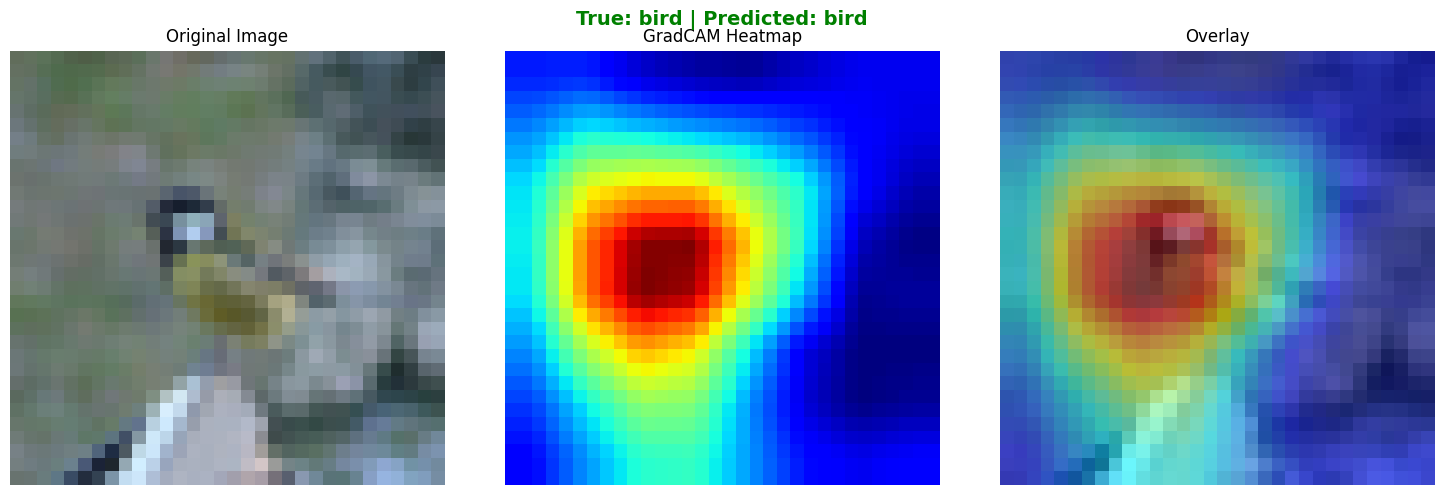


Image 4684: True label = automobile


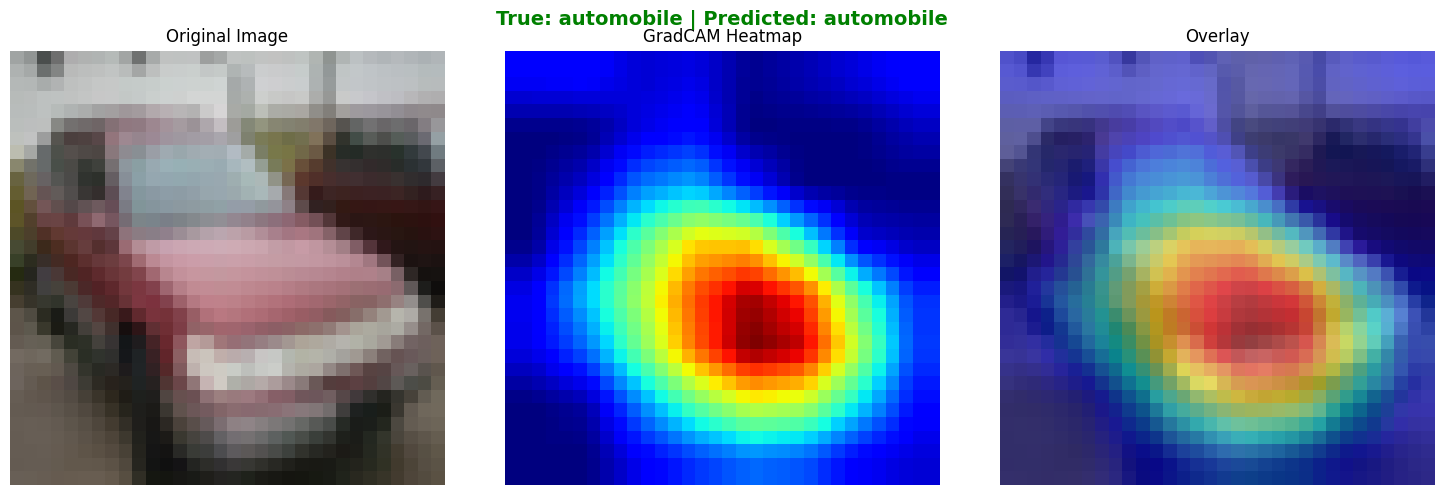


Image 1731: True label = dog


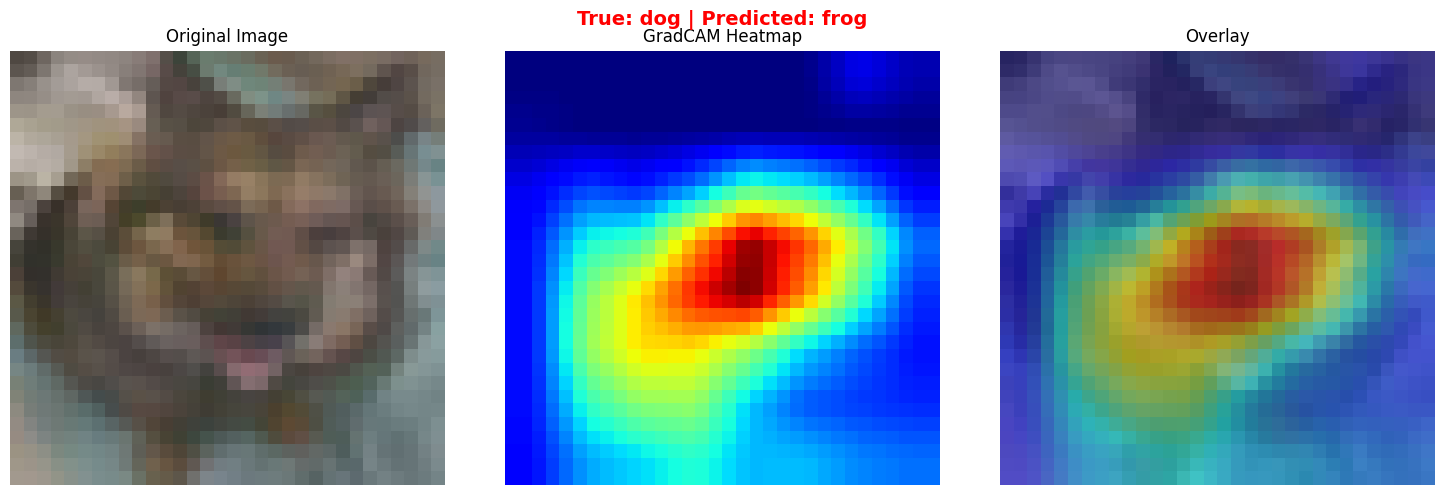


Image 4742: True label = ship


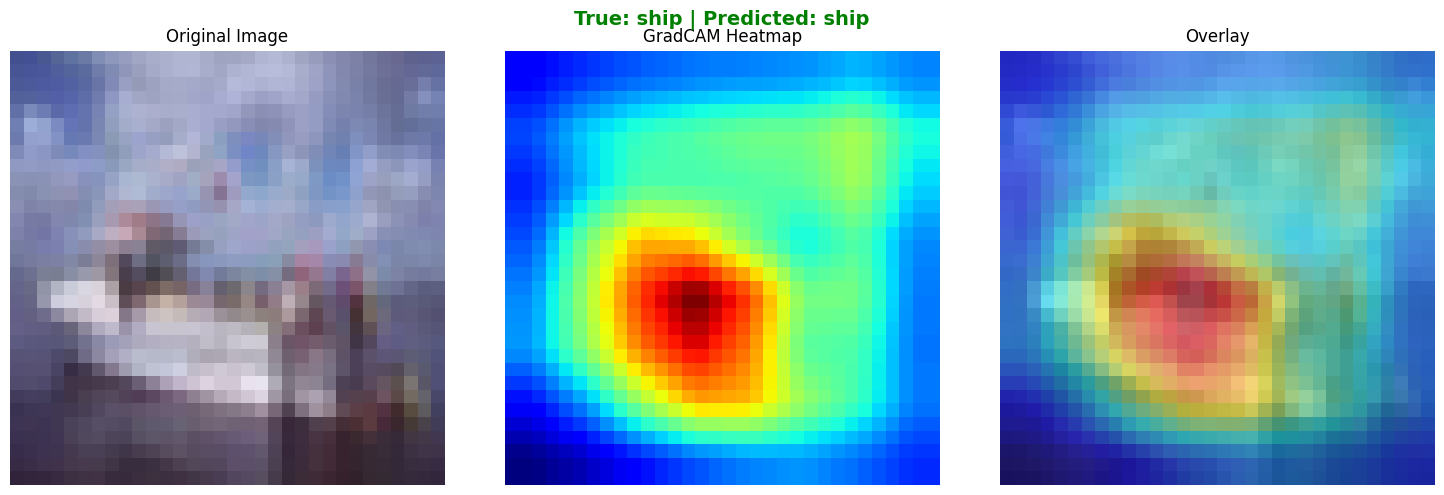


Image 4521: True label = truck


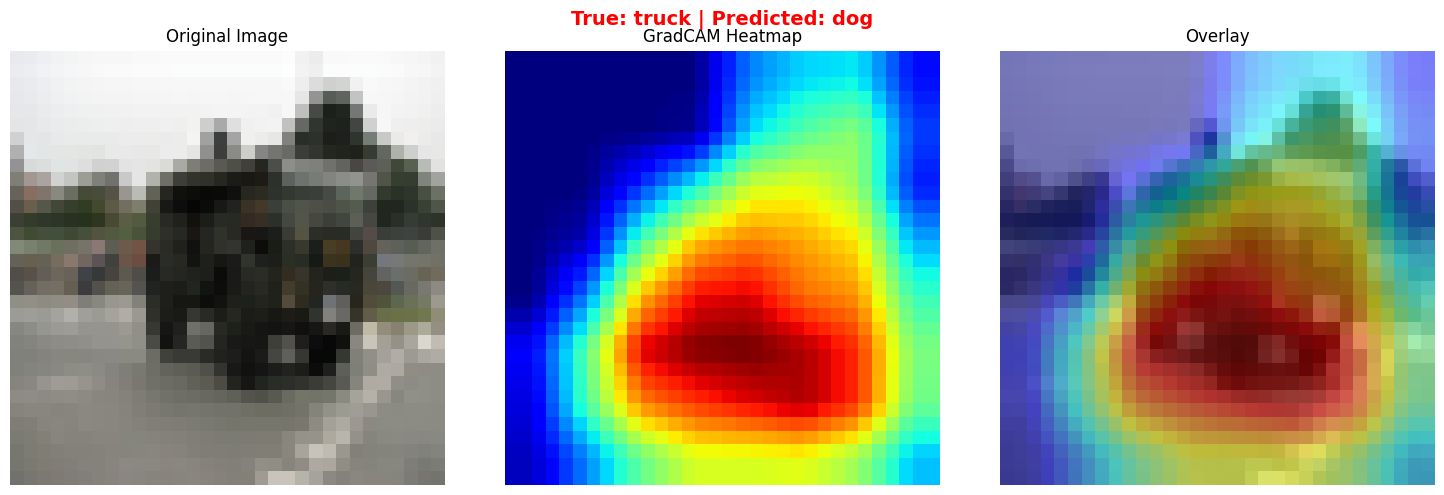

In [ ]:
# Visualize GradCAM for sample images
print("GradCAM Visualizations")
print("="*50)

# Get unnormalized dataset for visualization
viz_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True,
    transform=transforms.ToTensor()
)

# Visualize for 5 random images
np.random.seed(42)
sample_indices = np.random.choice(len(test_dataset), 5, replace=False)

for idx in sample_indices:
    image, label = test_dataset[idx]
    print(f"\nImage {idx}: True label = {CLASS_NAMES[label]}")
    visualize_gradcam(model, target_layer, image, label, CLASS_NAMES, device)


GradCAM Across Different Layers


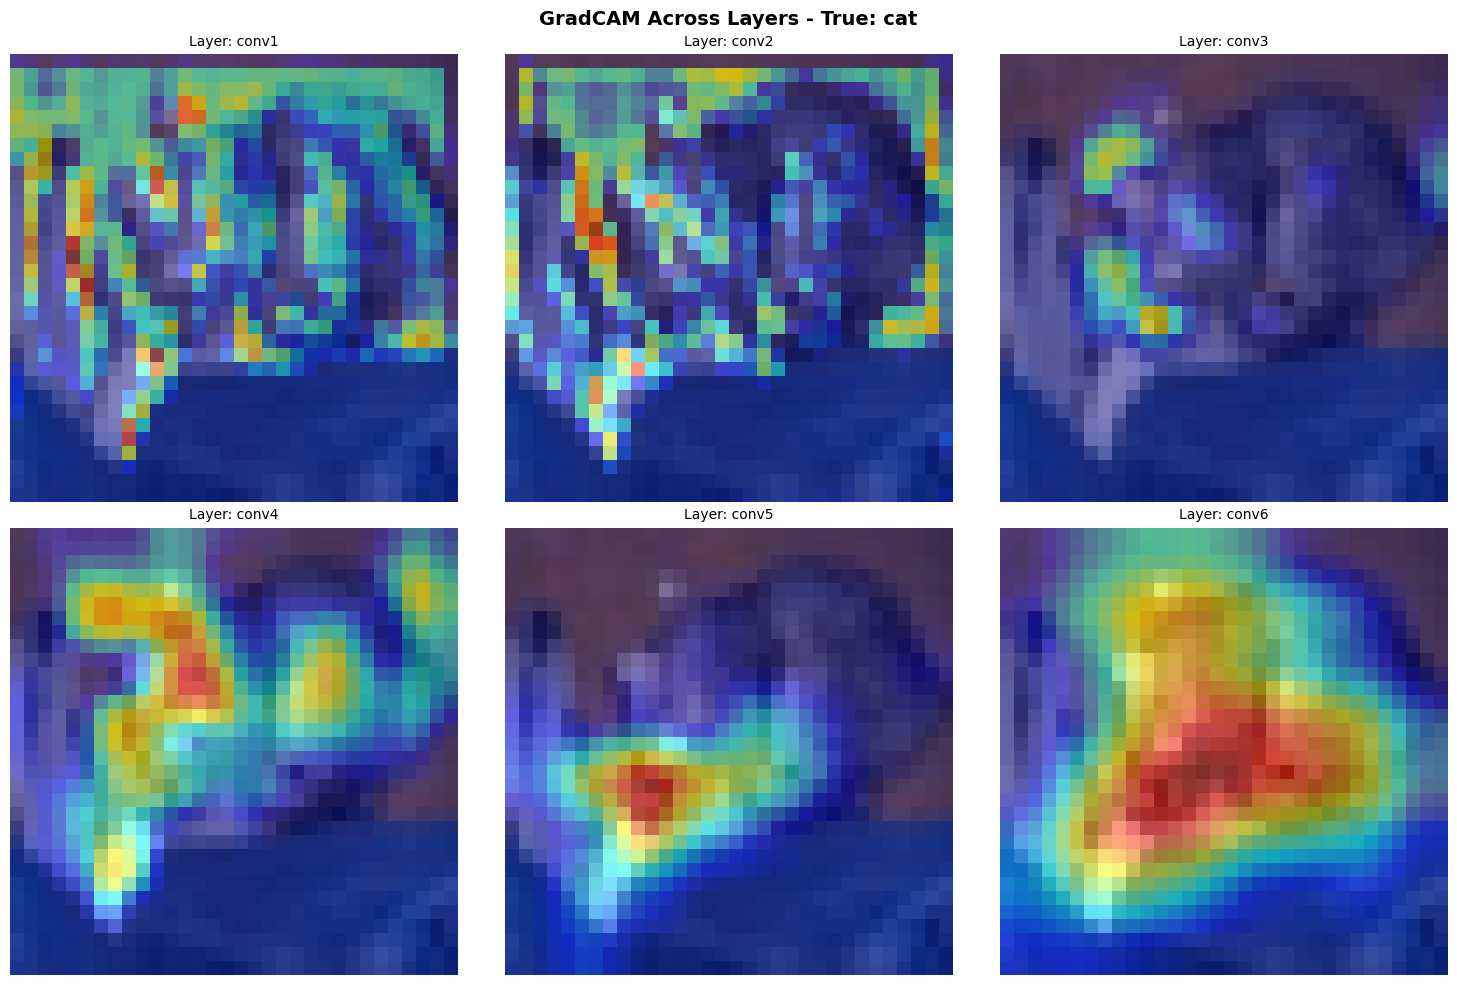

In [ ]:
# Visualize GradCAM across different layers
print("\nGradCAM Across Different Layers")
print("="*50)

image, label = test_dataset[0]
visualize_gradcam_multiple_layers(model, image, label, CLASS_NAMES, device)

## Part 7: Analysis Questions

In [ ]:
# Summary (provided)
print("="*60)
print("MODEL SUMMARY")
print("="*60)
print(f"Total Parameters: {count_parameters(model):,}")
print(f"Final Test Accuracy: {history['test_acc'][-1]:.2f}%")
print(f"Best Test Accuracy: {max(history['test_acc']):.2f}%")

MODEL SUMMARY
Total Parameters: 289,194
Final Test Accuracy: 82.23%
Best Test Accuracy: 82.38%


### 📝 Analysis Questions

**Question 1:** Describe the architecture choices you made to keep parameters under 1M. What trade-offs did you consider?

**Question 2:** How do forward and backward hooks work in PyTorch? Why are they essential for GradCAM?

**Question 3:** Looking at the GradCAM visualizations across different layers, what patterns do you observe? How does the attention change from early to late layers?

**Question 4:** For which types of images does GradCAM produce meaningful attention maps? Are there cases where it fails?

**Your Answers:**

*[Double-click to edit this cell and write your answers here]*

**Answer 1:**
To keep the model under the 1-millionparameter limit, I designed a moderately deep CNNwith a gradualincrease in channel width (32-. 64 -> 128) instead of using very wide layers. Each stage consists of two 3x3 convolutional layers followed by batch normalizationand ReLU,which allows the network to learn expressive features without a large parameter increse.
Max pooling is ued after ech block tprogressively reduce spatial dimensions, which significantly lowers computational cost. Instead of using large fully connected layers at the end, I usedGlobal aveage Pooling(GAP)followed by a single linear layerThis removes the need forthousands of parameters that would otherwise be required by dese layers.
The main trade-offwas depth versus width.Increasing depth improves feature learning but risksoverfitting, while wider layers increase parameters quickly. I balanced this by keeping the network deep enough for good representation learning while using dropout and bach normalization to maintain generalization. This design achievd strong performance(82% accuracy) while staying well below the parameter budge289k parameters).


**Answer 2:**
Forward and backward hooks in PyTorch are callback functions that allow access to intermediatevalues dring the forward and backward passes withoutmodifying themodel architecture.
A forward hook is triggered after a layer computes its output during the forwad pass.In GradCAMthis is used tocapture theactivation maps of a target convolutional layer,which preservespatial information aboutwhere features are detected in the image.
A backward hok is triggered during backpropagatihvon and captures the gradients of the target class score with respect tohe activation maps.Thse gradients indicate how important each featurje map is for the final Prediction.
GraCAM relies on both of these hooks: the gradients are globally averaged to compute importance weights,which are then combined withthe forward activations to produce    a class-discriminative localization map.Without hooks,it would not be possible to access these internal signals needed to compute GradCAM.


**Answer 3:**
The GrdCAM visualizations show a clear progression of attention from early to late layers. Iearly convolutionallayers,the atention maps tend tohighlight simple structures such as edges, corners,and local color contrasts.These maps are oftendiffuse and spread across large regions of the image.
In the middle layers,attention becomes more focused o textures and object parts, such as animal fces ovehicle contours. Thehighlighted regions are more localized but still cover multiple parts of the object.
In the final convolutional layers, the attention maps are highlyconcentrated on the most semntically relevant regions of the object, such as the body of an animal or the main structure of a vehicleTh=is demonstrates that deeper layers capture higher-level,class-specificfeatures, which aligns with the hierarchical nature of CNNs.


**Answer 4:**
GradCM produces the most meaningful attention maps for images where the object is clearly visible, centrally located,and hadistinctive visualfeatures. For example,images of vehicles or animals with clear shapes tendto producfocused and interpretablheatmaps.
However, GradCAM can be less reliable when images contain cluttered backgrounds, multiple bjects,or visuallysimilar classessuch as cats and dogs).In these cases, attention maps may be difuse or focus on background regions that correlate with the class rather than the object itself. GradCAM may also struggle when the model is uncertain ormisclassifies an imge, as the highlighted regions do not always correspond to human-interpretable features.